In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('UberDataset.csv',lineterminator='\n')

In [ ]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE\r
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain\r
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,\r
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies\r
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting\r
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit\r


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
    1156 non-null   object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [ ]:
df.describe()

,MILES
count,1156.000000
mean,21.115398
std,359.299007
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,12204.700000


In [ ]:
df.isnull().sum()

START_DATE    0
END_DATE      1
CATEGORY      1
START         1
STOP          1
MILES         0
PURPOSE\r     0
dtype: int64

In [ ]:
df.columns

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE\r'],
      dtype='object')

In [ ]:
from datetime import datetime

df['START_DATE'] = pd.to_datetime(df['START_DATE'],errors='coerce')
print(df['START_DATE'].dtypes)


datetime64[ns]


In [ ]:
from datetime import datetime

df['END_DATE'] = pd.to_datetime(df['END_DATE'],errors='coerce')
print(df['END_DATE'].dtypes)

datetime64[ns]


In [ ]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE\r
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain\r
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,\r
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies\r
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting\r
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit\r


In [ ]:
from datetime import datetime

df['DATE'] = pd.DatetimeIndex(df['START_DATE']).date

In [ ]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE\r,DATE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain\r,2016-01-01
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,\r,2016-01-02
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies\r,2016-01-02
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting\r,2016-01-05
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit\r,2016-01-06


In [ ]:
df['TIME'] = pd.DatetimeIndex(df['START_DATE']).hour

In [ ]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE\r,DATE,TIME
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain\r,2016-01-01,21.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,\r,2016-01-02,1.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies\r,2016-01-02,20.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting\r,2016-01-05,17.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit\r,2016-01-06,14.0


In [ ]:
df['DAY-NIGHT'] = pd.cut(x=df['TIME'],bins=[0,10,15,19,24],labels=['morning','afternoon','evening','night'])

In [ ]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE\r,DATE,TIME,DAY-NIGHT
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain\r,2016-01-01,21.0,night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,\r,2016-01-02,1.0,morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies\r,2016-01-02,20.0,night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting\r,2016-01-05,17.0,evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit\r,2016-01-06,14.0,afternoon


# DATA VISUALISATION

AttributeError: module 'matplotlib.pyplot' has no attribute 'countplot'

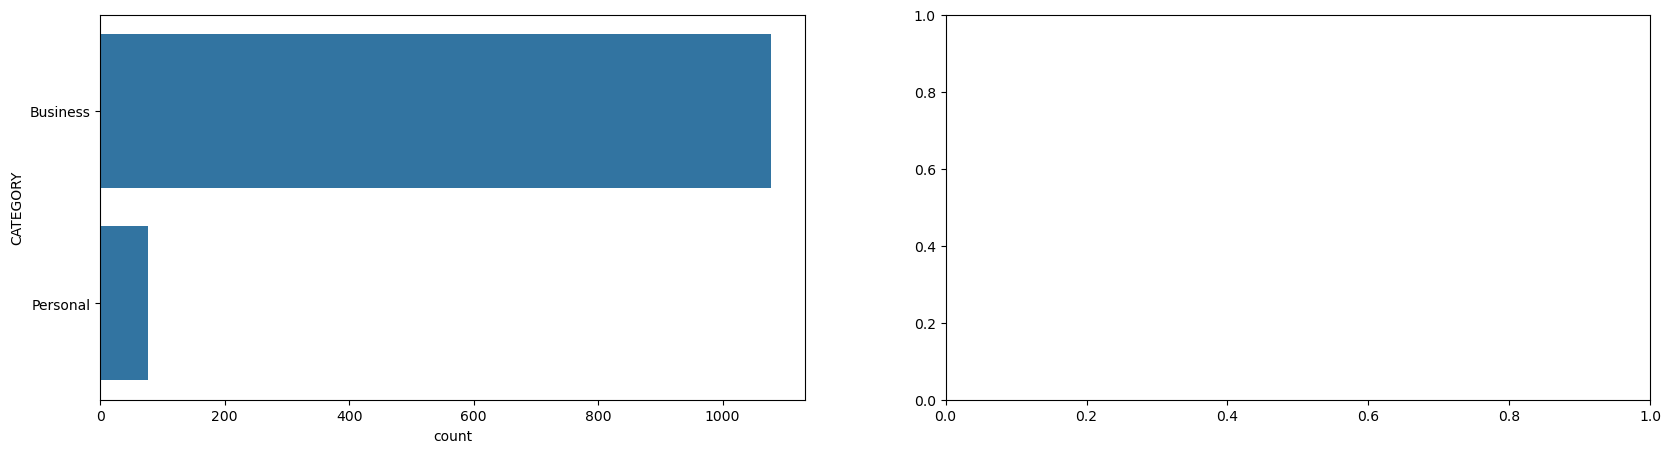

In [ ]:
plt.figure(figsize=(20,5))


plt.subplot(1,2,1)
sns.countplot(df['CATEGORY'])

plt.subplot(1,2,2)
plt.countplot(df['PURPOSE'])

In [ ]:
sns.countplot(df['DAY-NIGHT'])

In [ ]:
df['MONTHS'] = pd.DatetimeIndex(df['START_DATE']).month

months_label = {1.0:'jan',2.0:'feb',3.0:'mar',4.0:'apr',5.0:'may',6.0:'jun',7.0:'jul',8.0:'aug',9.0:'sep',10.0:'oct',11.0:'nov',12.0:'dec'}

df['MONTHS'] = df.MONTHS.map(months_label)

mon = df.MONTHS.value_counts(sort=False)

In [ ]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE\r,DATE,TIME,DAY-NIGHT,MONTHS
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain\r,2016-01-01,21.0,night,jan
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,\r,2016-01-02,1.0,morning,jan
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies\r,2016-01-02,20.0,night,jan
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting\r,2016-01-05,17.0,evening,jan
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit\r,2016-01-06,14.0,afternoon,jan


In [ ]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE\r,DATE,TIME,DAY-NIGHT,MONTHS
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain\r,2016-01-01,21.0,night,jan
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,\r,2016-01-02,1.0,morning,jan
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies\r,2016-01-02,20.0,night,jan
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting\r,2016-01-05,17.0,evening,jan
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit\r,2016-01-06,14.0,afternoon,jan


In [ ]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE\r,DATE,TIME,DAY-NIGHT,MONTHS
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain\r,2016-01-01,21.0,night,jan
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,\r,2016-01-02,1.0,morning,jan
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies\r,2016-01-02,20.0,night,jan
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting\r,2016-01-05,17.0,evening,jan
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit\r,2016-01-06,14.0,afternoon,jan
...,...,...,...,...,...,...,...,...,...,...,...
1151,NaT,NaT,Business,Kar?chi,Unknown Location,3.9,Temporary Site\r,NaT,NaN,NaN,NaN
1152,NaT,NaT,Business,Unknown Location,Unknown Location,16.2,Meeting\r,NaT,NaN,NaN,NaN
1153,NaT,NaT,Business,Katunayake,Gampaha,6.4,Temporary Site\r,NaT,NaN,NaN,NaN
1154,NaT,NaT,Business,Gampaha,Ilukwatta,48.2,Temporary Site\r,NaT,NaN,NaN,NaN


[Text(0.5, 0, 'MONTHS'), Text(0, 0.5, 'VALUE COUNT')]

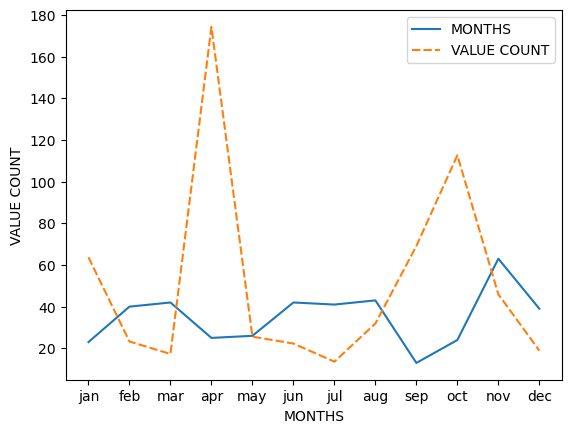

In [ ]:
df =pd.DataFrame({
    'MONTHS':mon.values,
    'VALUE COUNT':df.groupby('MONTHS',sort=False)['MILES'].max()
})

p = sns.lineplot(data=df)
p.set(xlabel='MONTHS',ylabel='VALUE COUNT')
    

In [ ]:
df['DAY'] = df.START_DATE.dt.weekday

day_label = {0:'mon',1:'tues',2:'wed',3:'thurs',4:'fri',5:'sat',6:'sun'}

df['DAY'] = df['DAY'].map(day_label)

AttributeError: 'DataFrame' object has no attribute 'START_DATE'

In [ ]:
df.columns


Index(['MONTHS', 'VALUE COUNT'], dtype='object')